# Customer Churn Prediction

# Feature Engineering & Feature Selection

## Objective

Identify the most influential features affecting customer churn using statistical
and machine learning techniques. The selected features will be used to train
XGBoost and CatBoost models.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

import joblib

print("Libraries Loaded Successfully!")

Libraries Loaded Successfully!


In [2]:
df = pd.read_csv("../data/cleaned_telco.csv")

print(df.shape)

df.head()

(7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [4]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

print(X.shape)
print(y.shape)

(7043, 19)
(7043,)


In [5]:
le = LabelEncoder()

y = le.fit_transform(y)

print(np.unique(y))

[0 1]


In [6]:
# Create a copy
corr_df = df.copy()

# Encode categorical columns
for col in corr_df.select_dtypes(include="object").columns:
    corr_df[col] = LabelEncoder().fit_transform(corr_df[col])

In [7]:
corr = corr_df.corr()["Churn"].sort_values(
    key=abs,
    ascending=False
)

corr

Churn               1.000000
Contract           -0.396713
tenure             -0.352229
OnlineSecurity     -0.289309
TechSupport        -0.282492
TotalCharges       -0.198324
OnlineBackup       -0.195525
MonthlyCharges      0.193356
PaperlessBilling    0.191825
DeviceProtection   -0.178134
Dependents         -0.164221
SeniorCitizen       0.150889
Partner            -0.150448
PaymentMethod       0.107062
InternetService    -0.047291
StreamingMovies    -0.038492
MultipleLines       0.038037
StreamingTV        -0.036581
PhoneService        0.011942
gender             -0.008612
Name: Churn, dtype: float64

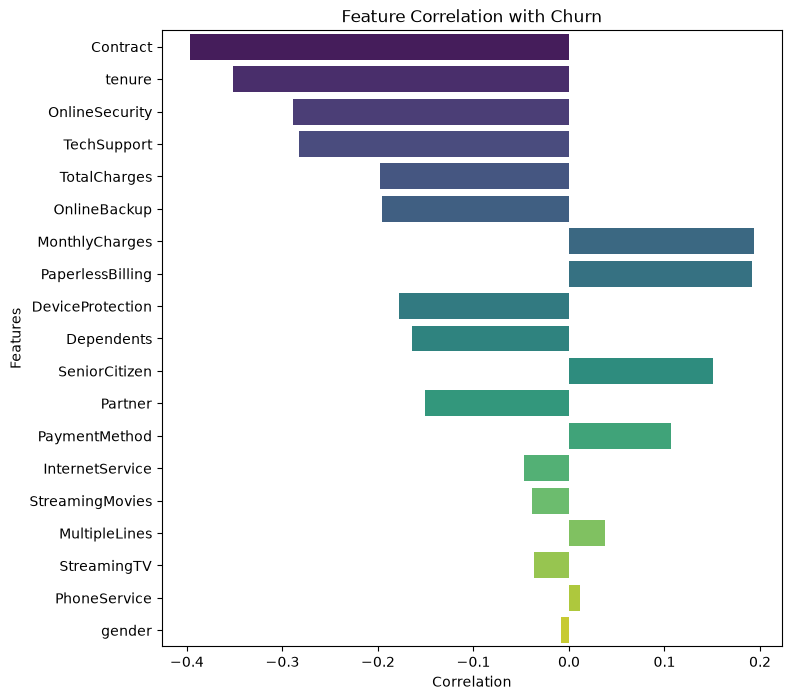

In [8]:
plt.figure(figsize=(8,8))

sns.barplot(
    x=corr.values[1:],
    y=corr.index[1:],
    palette="viridis"
)

plt.title("Feature Correlation with Churn")

plt.xlabel("Correlation")

plt.ylabel("Features")

plt.show()

In [9]:
mi_df = df.copy()

for col in mi_df.select_dtypes(include="object").columns:
    mi_df[col] = LabelEncoder().fit_transform(mi_df[col])

In [10]:
X_mi = mi_df.drop("Churn", axis=1)

y_mi = mi_df["Churn"]

In [11]:
mi_scores = mutual_info_classif(
    X_mi,
    y_mi,
    random_state=42
)

mi_scores = pd.Series(
    mi_scores,
    index=X_mi.columns
).sort_values(ascending=False)

mi_scores

Contract            0.091574
tenure              0.076971
OnlineSecurity      0.060872
TechSupport         0.059060
OnlineBackup        0.055694
InternetService     0.054400
PaymentMethod       0.047912
DeviceProtection    0.046260
MonthlyCharges      0.045334
TotalCharges        0.043268
StreamingMovies     0.030158
StreamingTV         0.030077
Dependents          0.020399
PaperlessBilling    0.020014
PhoneService        0.010758
SeniorCitizen       0.010019
Partner             0.007401
gender              0.001218
MultipleLines       0.000000
dtype: float64

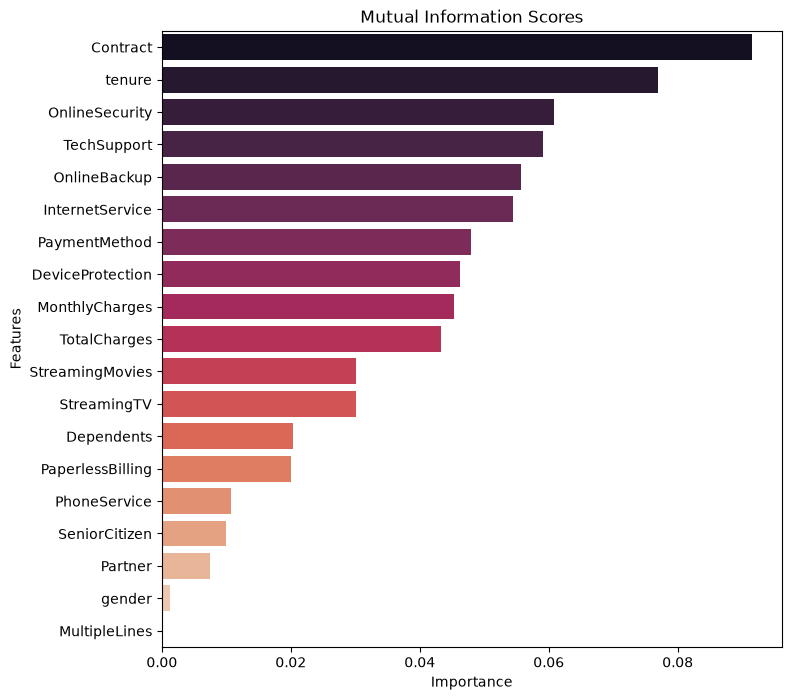

In [12]:
plt.figure(figsize=(8,8))

sns.barplot(
    x=mi_scores.values,
    y=mi_scores.index,
    palette="rocket"
)

plt.title("Mutual Information Scores")

plt.xlabel("Importance")

plt.ylabel("Features")

plt.show()